In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matlab.engine

from glob import glob

import sys
sys.path.append('../../wavelet/')
import wavelet_funcs as wf

import os
from scipy.ndimage import gaussian_filter

In [3]:
eng = matlab.engine.start_matlab()

### Load some data

In [12]:
dt = 0.5
Fs = 2
nt = 1024
t = np.arange(nt)*dt

# Dummy signal
fsignal = 0.03
amp = 5
x = 50 + amp*np.cos(2*np.pi*fsignal*t)

fsignal2 = 0.04
amp2 = 2
x2 = x + amp2*np.cos(2*np.pi*fsignal2*t)

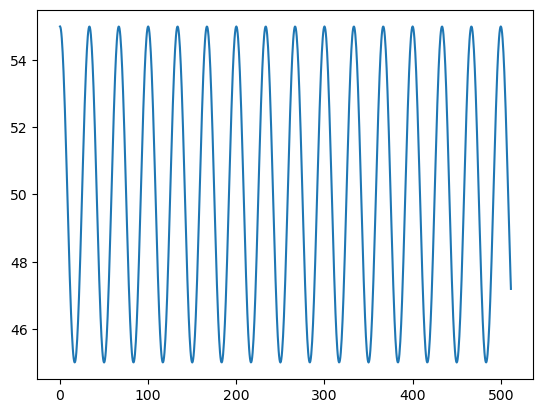

In [14]:
plt.plot(t,x)

In [91]:
res = wf.matlab_cwt(eng, x, Fs, time_bandwidth=60, frequency_limits=(0.01, 0.1))
res2 = wf.matlab_cwt(eng, x2, Fs, time_bandwidth=60, frequency_limits=(0.01, 0.1))

(-0.25, 511.75)

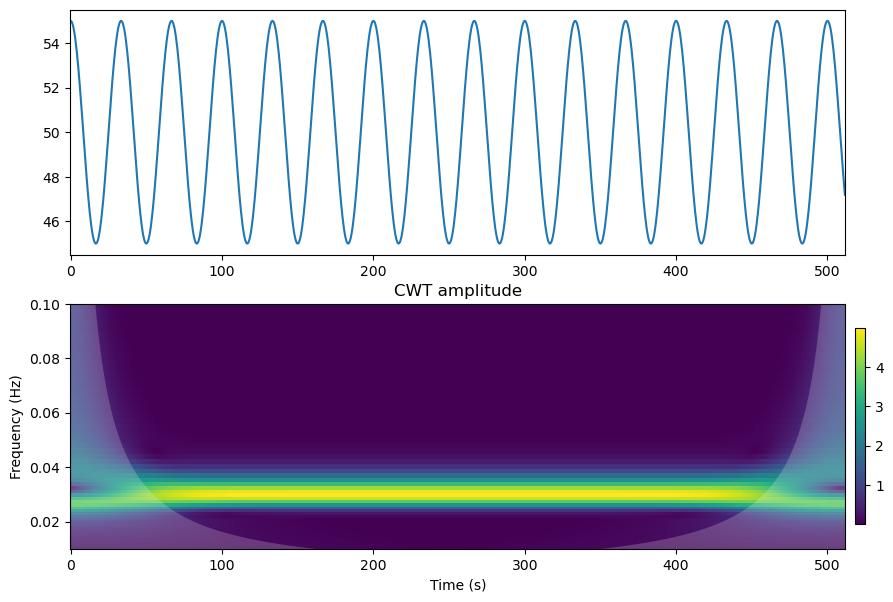

In [92]:
f, (ax0, ax) = plt.subplots(2,1,figsize=(10,7))
ax0.plot(t,x)
# wf.plot_cwt((res.wt_amp**2)*res.scale.data.reshape((res.scale.size, 1)), res.f, res.t, add_colorbar=True, ax=ax) # Power L2 norm
wf.plot_cwt(res.wt_amp, res.f, res.t, add_colorbar=True, ax=ax) # Amplitude L1 norm
# ax.set_yscale('log')

ax.fill_between(t, y1=res.coi, color='w', alpha=0.2, lw=0)

ax.set_ylim([res.f.min(), res.f.max()])
# ax.set_ylim([0.008, 0.105)
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title("CWT amplitude")

ax0.set_xlim(ax.get_xlim())
# plt.savefig('test.jpg', dpi=600, bbox_inches='tight')

(-0.25, 511.75)

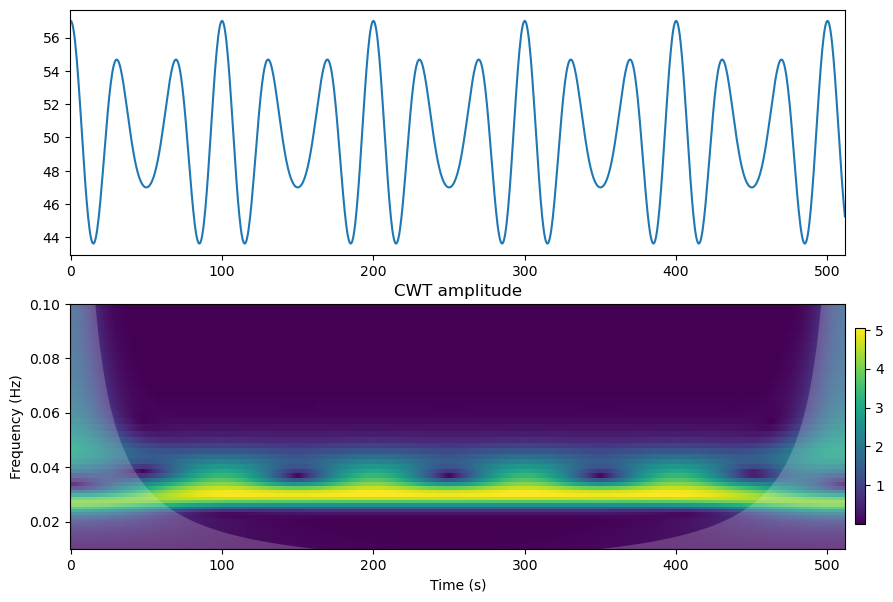

In [93]:
f, (ax0, ax) = plt.subplots(2,1,figsize=(10,7))
ax0.plot(t,x2)

wf.plot_cwt(res2.wt_amp, res2.f, res2.t, add_colorbar=True, ax=ax) # Amplitude L1 norm


ax.fill_between(t, y1=res2.coi, color='w', alpha=0.2, lw=0)

ax.set_ylim([res2.f.min(), res2.f.max()])
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title("CWT amplitude")

ax0.set_xlim(ax.get_xlim())
# plt.savefig('test.jpg', dpi=600, bbox_inches='tight')

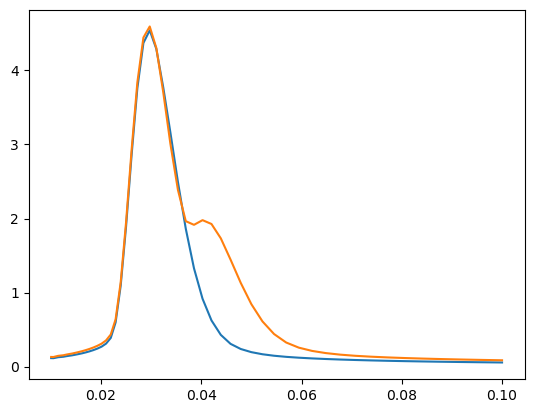

In [94]:
plt.plot(res.f[::-1], res.wt_amp.mean('t')[::-1])
plt.plot(res2.f[::-1], res2.wt_amp.mean('t')[::-1])

In [95]:
f_band = (res.f.max() - res.f.min())
e1 = np.trapezoid(res.wt_amp.mean('t')[::-1]**2, x=res.f[::-1]) / f_band
e2 = np.trapezoid(res2.wt_amp.mean('t')[::-1]**2, x=res2.f[::-1]) / f_band

In [100]:
np.sqrt(e2)/np.sqrt(e1) # Changes with CWT TimeBandwidth

<xarray.DataArray 'f' ()> Size: 8B
array(1.09074844)

In [97]:
np.sqrt(amp2**2+amp**2)/amp

np.float64(1.0770329614269007)

In [102]:
eng.quit()